<a href="https://colab.research.google.com/github/sanodyaJinadasa/InspiHER_Hacktronix/blob/main/ML_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Student Performance Prediction

##### This project focuses on predicting whether a student will pass or fail an exam using Machine Learning techniques. The dataset contains information about students’ study hours, attendance percentage, and exam results.

##### The main objective is to build a best classification model that can accurately predict student performance based on input features.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [27]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
file_path = '/content/drive/MyDrive/Outliers.ipynb/Final_Marks_Data.csv'
df = pd.read_csv(file_path)

In [29]:
print(df.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  
0                  3                             72  
1                  3                             56  
2                  3                             56  
3                  3            

In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None


In [31]:
print(df.isnull().sum())

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [32]:
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [33]:
df.duplicated().sum()

np.int64(0)

#Pre Processing

In [34]:
df = df.dropna()

In [35]:
df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

In [36]:
print(df.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100) Result  
0                  3                             72   Pass  
1                  3                             56   Pass  
2                  3                             56   Pass  
3   

Feature Engineering

CA_Average

In [37]:
df['CA_Average'] = (
    df['Internal Test 1 (out of 40)'] +
    df['Internal Test 2 (out of 40)'] +
    (df['Assignment Score (out of 10)'] * 4)
) / 3

Study Efficiency Score

In [38]:
df['Study_Efficiency'] = (
    df['Attendance (%)'] *
    df['Daily Study Hours']
) / 10

# Outlier Detection and Treatment

In [39]:
invalid_rows = df[
    (df['Attendance (%)'] < 0) | (df['Attendance (%)'] > 100) |
    (df['Internal Test 1 (out of 40)'] < 0) | (df['Internal Test 1 (out of 40)'] > 40) |
    (df['Internal Test 2 (out of 40)'] < 0) | (df['Internal Test 2 (out of 40)'] > 40) |
    (df['Assignment Score (out of 10)'] < 0) | (df['Assignment Score (out of 10)'] > 10) |
    (df['Final Exam Marks (out of 100)'] < 0) | (df['Final Exam Marks (out of 100)'] > 100) |
    (df['Daily Study Hours'] < 0) | (df['Daily Study Hours'] > 16)
]

print(invalid_rows)

Empty DataFrame
Columns: [Student_ID, Attendance (%), Internal Test 1 (out of 40), Internal Test 2 (out of 40), Assignment Score (out of 10), Daily Study Hours, Final Exam Marks (out of 100), Result, CA_Average, Study_Efficiency]
Index: []


Domain-based outlier detection was initially performed using logical minimum and maximum boundary validation. Academic-related attributes such as attendance, internal test marks, assignment scores, and final examination marks possess predefined valid ranges according to institutional grading standards.Additionally, daily study hours were constrained between 0 and 16 hours based on practical human daily activity limitations including sleep and personal activities.

The output gives empty DataFrame. It means thee are no any value that more than its range

Box Plot Visualization

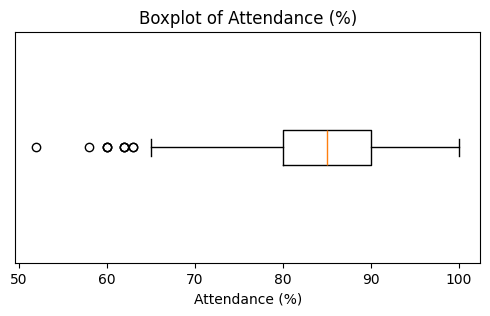

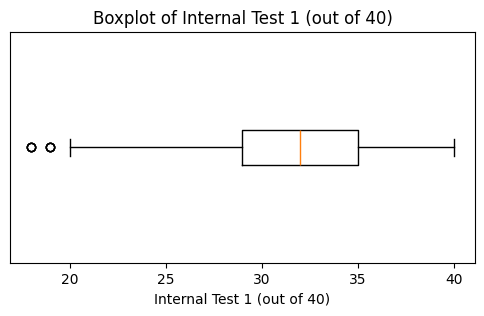

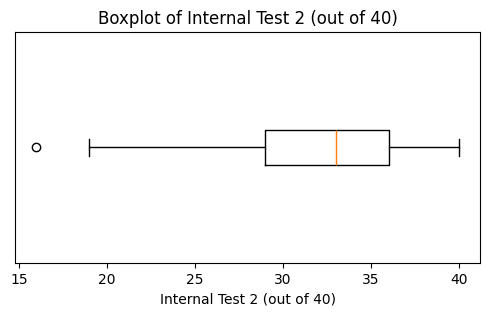

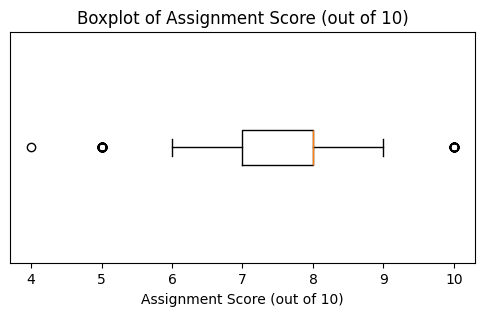

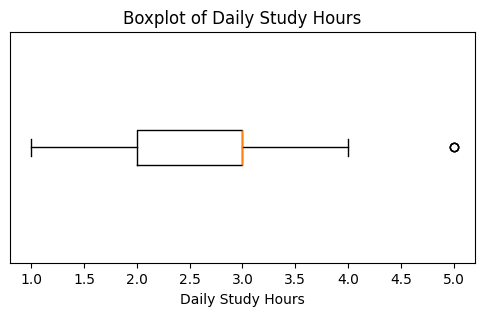

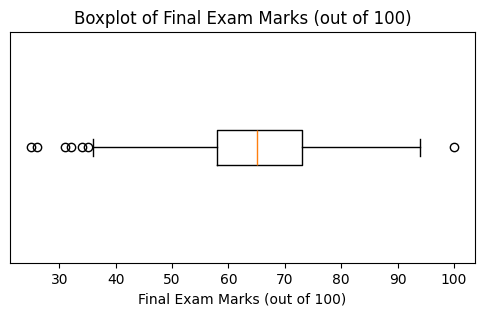

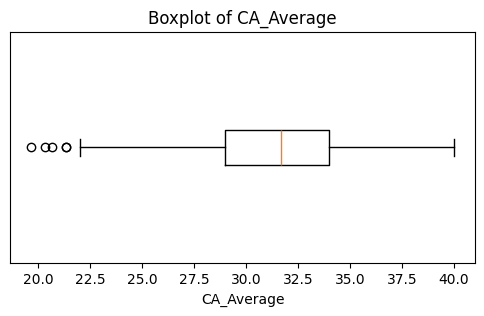

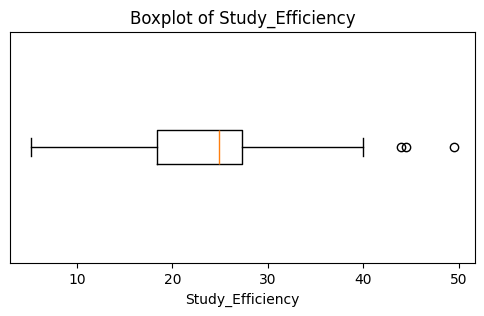

In [40]:
# numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Remove unwanted columns if they exist
#exclude_cols = ['Result']

#numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Create boxplots
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.yticks([])   # Removes index-like y-axis labels
    plt.show()

Detect Outliers Using IQR

In [41]:
numeric_cols = [
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours',
    'Final Exam Marks (out of 100)'
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Number of outliers: {len(outliers)}")
    print("\n")

Attendance (%)
Number of outliers: 10


Internal Test 1 (out of 40)
Number of outliers: 8


Internal Test 2 (out of 40)
Number of outliers: 1


Assignment Score (out of 10)
Number of outliers: 79


Daily Study Hours
Number of outliers: 3


Final Exam Marks (out of 100)
Number of outliers: 7




In [42]:
display(outliers)


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100),Result,CA_Average,Study_Efficiency
118,S1118,67,18,32,5,1,35,Fail,23.333333,6.7
678,S1678,60,23,16,5,2,31,Fail,19.666667,12.0
1007,S2007,100,40,40,8,3,100,Pass,37.333333,30.0
1194,S2194,68,21,26,5,1,26,Fail,22.333333,6.8
1205,S2205,70,19,21,6,2,32,Fail,21.333333,14.0
1564,S2564,52,20,21,5,1,25,Fail,20.333333,5.2
1614,S2614,72,26,21,6,3,34,Fail,23.666667,21.6


Although the IQR method detected some outliers, these values were considered normal and realistic for student performance data. Since they did not represent incorrect or impossible values, the outliers were not removed from the dataset.

# Feature Selection

In [43]:
X = df.drop(['Student_ID', 'Result'], axis=1)

y = df['Result']

In [44]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

converts:

Pass → 1,
Fail → 0

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1400, 8)
(600, 8)
(1400,)
(600,)


In the feature selection step, unnecessary columns such as Student_ID were removed because they do not contribute to predicting student results. The remaining attributes were used as input features, while the Result column was selected as the target variable. The target values were converted into numerical format using label encoding. After that, the dataset was divided into training and testing sets using an 70:30 ratio to evaluate model performance effectively.

# Class Balance Checking

In [49]:
print(pd.Series(y_train).value_counts())

1    1270
0     130
Name: count, dtype: int64


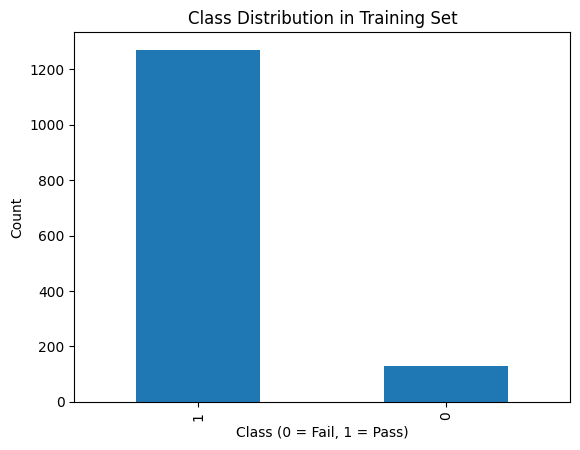

In [48]:
pd.Series(y_train).value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution in Training Set")
plt.xlabel("Class (0 = Fail, 1 = Pass)")
plt.ylabel("Count")
plt.show()

Apply SMOTE on Training Data

In [51]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [52]:
print(pd.Series(y_train_resampled).value_counts())

1    1270
0    1270
Name: count, dtype: int64


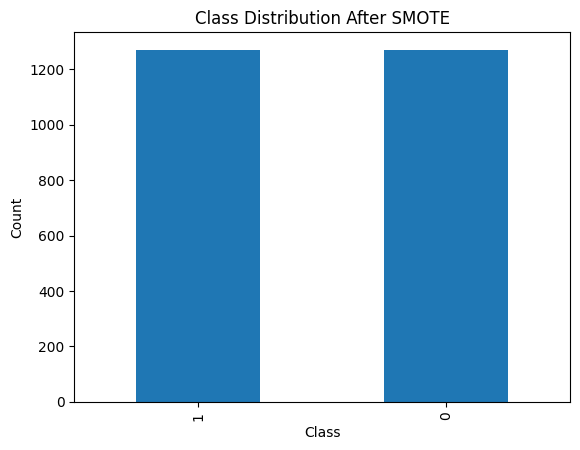

In [53]:
pd.Series(y_train_resampled).value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

SMOTE was applied only on the training dataset to avoid data leakage. It generates synthetic samples for the minority class (Fail) by interpolating existing data points. This helps to balance the dataset and improves the model’s ability to learn both classes equally.

# Training Models